# AirBnB
https://insideairbnb.com/get-the-data/

https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2025-12-28/data/listings.csv.gz

In [8]:
import pandas as pd

In [9]:
# df = pd.read_csv('../listings.csv')
df = pd.read_csv('https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/data/listings.csv.gz')

In [10]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,20260624212719,2026-06-25,city scrape,Quartos disponíveis no Recreio,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,546603190,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,20260624212719,2026-06-25,city scrape,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,737983482,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
2,42874066,https://www.airbnb.com/rooms/42874066,20260624212719,2026-06-25,city scrape,Alugo uma vaga para sexo feminino Recreio,NaN,NaN,https://a0.muscache.com/pictures/43e779d6-58df...,341395950,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            48713 non-null  int64  
 1   listing_url                                   48713 non-null  str    
 2   scrape_id                                     48713 non-null  int64  
 3   last_scraped                                  48713 non-null  str    
 4   source                                        48713 non-null  str    
 5   name                                          48713 non-null  str    
 6   description                                   47704 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   48713 non-null  str    
 9   host_id                                       48713 non-null  int64  
 1

In [12]:
df.room_type.value_counts()

room_type
Entire home/apt    39458
Private room        8621
Shared room          601
Hotel room            33
Name: count, dtype: int64

In [13]:
import plotly.express as px


quantidade_anuncios = df['room_type'].value_counts(ascending=False).reset_index()
grafico_remoto = px.pie(
    quantidade_anuncios,
    names='room_type',
    values='count',
    title='Proporção dos anúncios por tipo de quarto',
    hole=0.5,
    labels={
        'room_type': 'Tipo de Quarto', 
        'count': 'Quantidade'
    }
)
grafico_remoto.update_traces(textinfo='percent+label', pull=[0.05, 0, 0, 0])
grafico_remoto.update_layout(title_x=0.5)

In [14]:
df['len_name'] = df['name'].str.len().fillna(0).astype(int)
df['len_description'] = df['description'].str.len().fillna(0).astype(int)

In [15]:
col_interesse = ['id', 'name', 'len_description', 'len_name', 'host_name', 'host_location', 'host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [16]:
df_treatment = df[col_interesse].copy()

In [17]:
df_treatment.head(3)

,id,name,len_description,len_name,host_name,host_location,host_is_superhost,neighbourhood_cleansed,latitude,longitude,...,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating
0,1025196153924029661,Quartos disponíveis no Recreio,0,30,Ananda,NaN,f,Recreio dos Bandeirantes,-23.016320,-43.462606,...,Private room,2,4.0,2.0,2.0,NaN,1.0,0,0,NaN
1,1697400829368754530,Casa próxima a Floresta da Tijuca,77,33,Yuri,NaN,f,Alto da Boa Vista,-22.975611,-43.284655,...,Private room,2,1.0,1.0,1.0,$219.11,1.0,0,0,NaN
2,42874066,Alugo uma vaga para sexo feminino Recreio,0,41,Mabel,NaN,f,Recreio dos Bandeirantes,-23.022660,-43.492710,...,Private room,1,1.0,NaN,1.0,"$1,659.27",30.0,0,0,NaN


In [18]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [19]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      48713 non-null  int64  
 1   name                    48713 non-null  str    
 2   len_description         48713 non-null  int64  
 3   len_name                48713 non-null  int64  
 4   host_name               48712 non-null  str    
 5   host_location           37593 non-null  str    
 6   host_is_superhost       48712 non-null  str    
 7   neighbourhood_cleansed  48713 non-null  str    
 8   latitude                48713 non-null  float64
 9   longitude               48713 non-null  float64
 10  property_type           48713 non-null  str    
 11  room_type               48680 non-null  str    
 12  accommodates            48713 non-null  int64  
 13  bathrooms               41289 non-null  float64
 14  bedrooms                41614 non-null  float64
 

In [20]:
df.neighbourhood_cleansed.value_counts()

neighbourhood_cleansed
Copacabana                  15036
Ipanema                      3928
Barra da Tijuca              3759
Centro                       3295
Recreio dos Bandeirantes     2477
                            ...  
Ribeira                         2
Turiaçú                         2
Campo dos Afonsos               1
Complexo do Alemão              1
Parque Colúmbia                 1
Name: count, Length: 154, dtype: int64

In [21]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [22]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)

In [23]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [24]:
pd.set_option('display.max_rows', 10)

In [25]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [26]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

In [27]:
df_treatment.to_csv("../data/AirBnBLimpo.csv")

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [37]:
!pip --version plotly

pip 26.1.2 from /home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pip (python 3.14)


In [ ]:
import plotly.graph_objects as go

df_tratamento = df_treatment.dropna(subset=['price_cleaned', 'latitude', 'longitude', 'neighbourhood_cleansed']).copy()

df_bairros = (
    df_tratamento.groupby("neighbourhood_cleansed")
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        total_anuncios=("neighbourhood_cleansed", "count"),
        preco_medio=("price_cleaned", "mean"),
    )
    .reset_index()
)

limits = [(0, 10), (10, 50), (50, 100), (100, 1000), (1000, 20000)]
colors = ["royalblue", "crimson", "lightseagreen", "orange", "lightgrey"]

marker_sizes = [10, 15, 20, 25, 35]

fig = go.Figure()


for i in range(len(limits)):
    lim_inf, lim_sup = limits[i]

    df_sub = df_bairros[
        (df_bairros["total_anuncios"] >= lim_inf)
        & (df_bairros["total_anuncios"] < lim_sup)
    ]

    hover_text = [
        f"<b>{row['neighbourhood_cleansed']}</b><br>"
        f"Total de Anúncios: {row['total_anuncios']}<br>"
        f"Preço Médio: R$ {row['preco_medio']:.2f}"
        for _, row in df_sub.iterrows()
    ]

    fig.add_trace(
        go.Scattermapbox(
            lat=df_sub["latitude"],
            lon=df_sub["longitude"],
            mode="markers",
            marker=dict(
                size=marker_sizes[i],
                color=colors[i],
                opacity=0.8,
            ),
            name=f"{lim_inf} - {lim_sup}",
            text=hover_text,
            hoverinfo="text",
        )
    )

fig.update_layout(
    title="Anúncios do Airbnb por Bairro no Rio de Janeiro",
    autosize=True,
    hovermode="closest",
    showlegend=True,
    legend=dict(
        title="Intervalo de Anúncios", traceorder="normal"
    ),
    mapbox=dict(
        style="carto-positron",
        zoom=10,
        center=dict(lat=-22.92, lon=-43.45),
    ),
    height=600,
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
)

fig.show()

/tmp/ipykernel_14223/631892434.py:48: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/tmp/ipykernel_14223/631892434.py:48: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/tmp/ipykernel_14223/631892434.py:48: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/tmp/ipykernel_14223/631892434.py:48: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/tmp/ipykernel_14223/631892434.py:48: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(


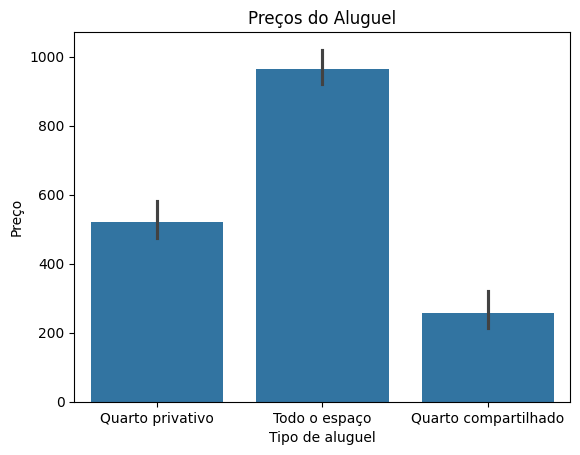

In [250]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

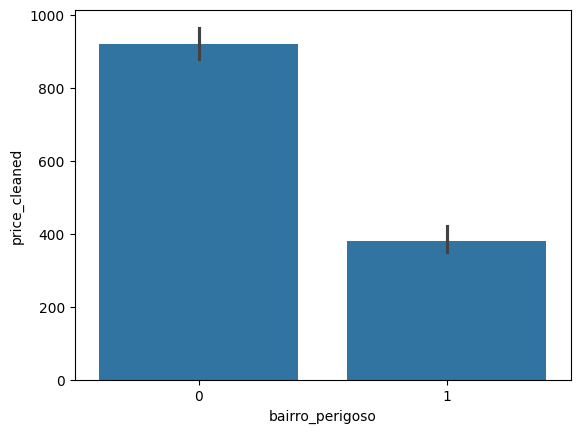

In [251]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

In [252]:
df_treatment.minimum_nights.describe()

count    48706.000000
mean         3.139264
std         13.706673
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        730.000000
Name: minimum_nights, dtype: float64

In [253]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 48713 entries, 0 to 48712
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      48713 non-null  int64  
 1   name                    48713 non-null  str    
 2   len_description         48713 non-null  int64  
 3   len_name                48713 non-null  int64  
 4   host_name               48712 non-null  str    
 5   host_location           37593 non-null  str    
 6   host_is_superhost       48713 non-null  bool   
 7   neighbourhood_cleansed  48713 non-null  str    
 8   latitude                48713 non-null  float64
 9   longitude               48713 non-null  float64
 10  property_type           48713 non-null  str    
 11  room_type               48680 non-null  str    
 12  accommodates            48713 non-null  int64  
 13  bathrooms               41289 non-null  float64
 14  bedrooms                41614 non-null  float64
 

In [254]:
df_treatment.price_cleaned.describe()

count     44542.000000
mean        877.707421
std        4599.612177
min           5.540000
25%         296.710000
50%         452.670000
75%         761.537500
max      574013.000000
Name: price_cleaned, dtype: float64

**💡 Evidência de Outliers nos Preços**

A distribuição dos preços apresenta fortes indícios de valores discrepantes (outliers):

- Média inflacionada: A média está em 4.388, enquanto o terceiro quartil (75%) é de apenas 565 (ou seja, 75% dos anúncios custam até 565).
- Alta dispersão: O desvio padrão supera o valor do próprio percentil de 75%, mostrando uma variação extrema.
- Máximo discrepante: O valor máximo está excessivamente alto em comparação com o restante dos dados.

Ação: Vamos realizar o corte (trimming) desses outliers acima de 1000 para normalizar a análise.

In [255]:
df_treatment = df_treatment[df_treatment["price_cleaned"] <=5000] 
df_treatment.price_cleaned.describe()

count    43744.000000
mean       641.015568
std        619.680744
min          5.540000
25%        293.500000
50%        445.060000
75%        735.000000
max       5000.000000
Name: price_cleaned, dtype: float64

In [256]:
df_treatment.price_cleaned.size/39816

1.098653807514567

Perdemos somentos 7400 dados de 39800 dados, então não perderemos tantos dados que afete a nossa análise

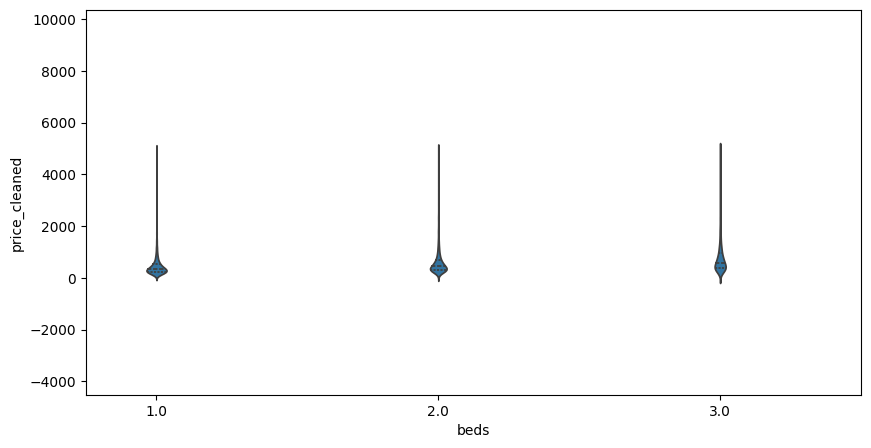

In [257]:
import seaborn as sns

plt.figure(figsize=[10,5])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()


0 camas nos anuncios? Provavelmente algum erro dos anuncios, portanto vamos verificar a quantidade que isso ocorre, se o melhor a se fazer é limpar, ou arrumar automaticamente

In [258]:
print("A quantidade de quartos com 0 camas é:", len(df_treatment[df_treatment["beds"] == 0]))

print("A quantidade total de anuncios é:", len(df_treatment))

A quantidade de quartos com 0 camas é: 0
A quantidade total de anuncios é: 43744


Pode ser limpo esses dados sem problemas na análise

In [259]:
df_treatment = df_treatment[df_treatment["beds"]>0]

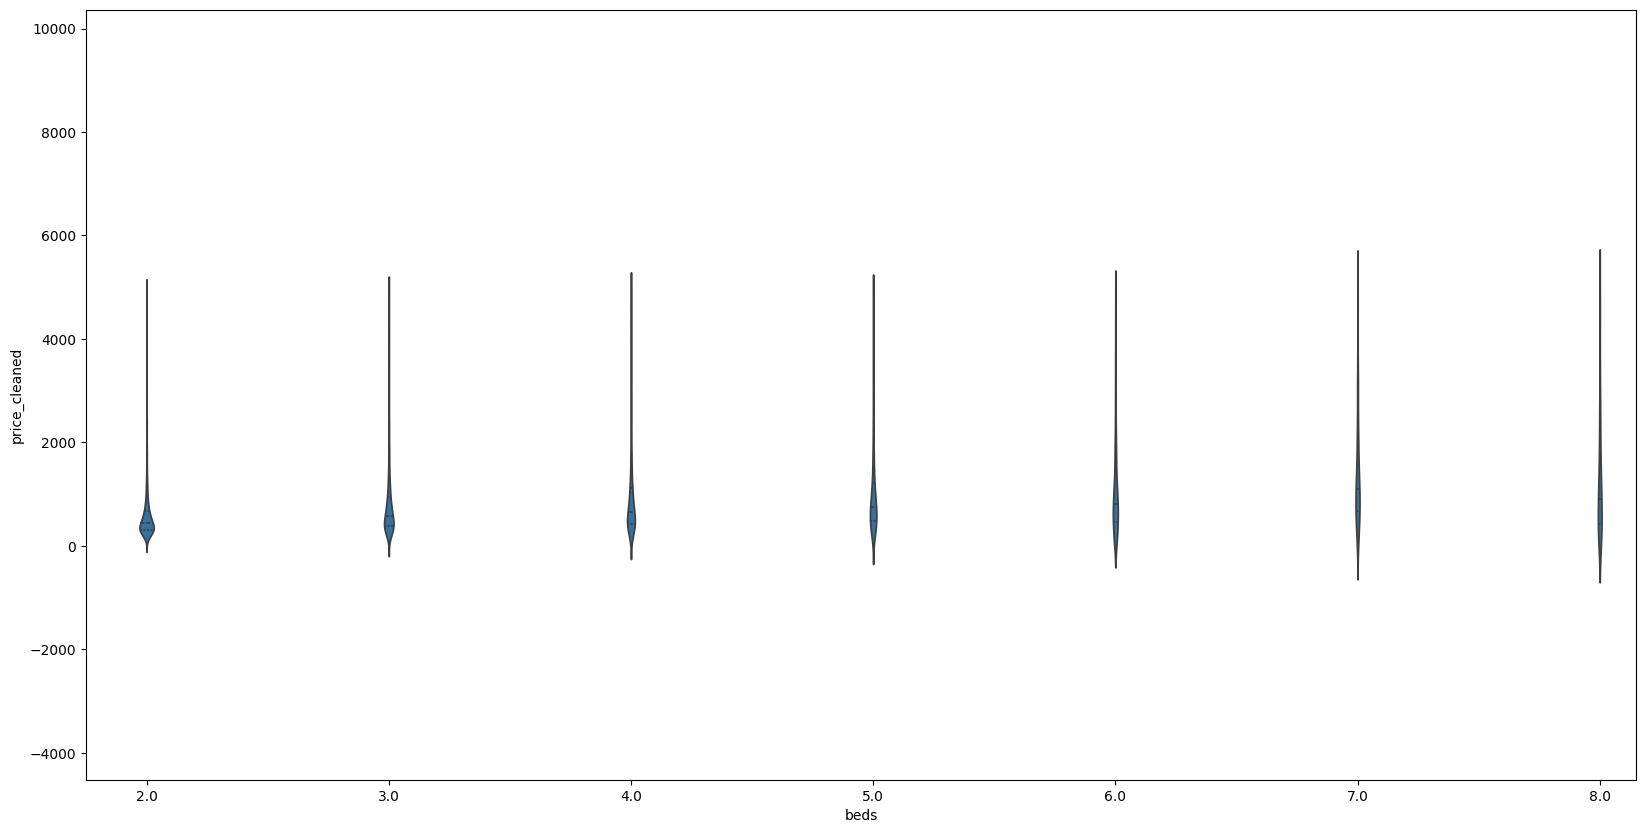

In [260]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(.75,7.15)

plt.show()


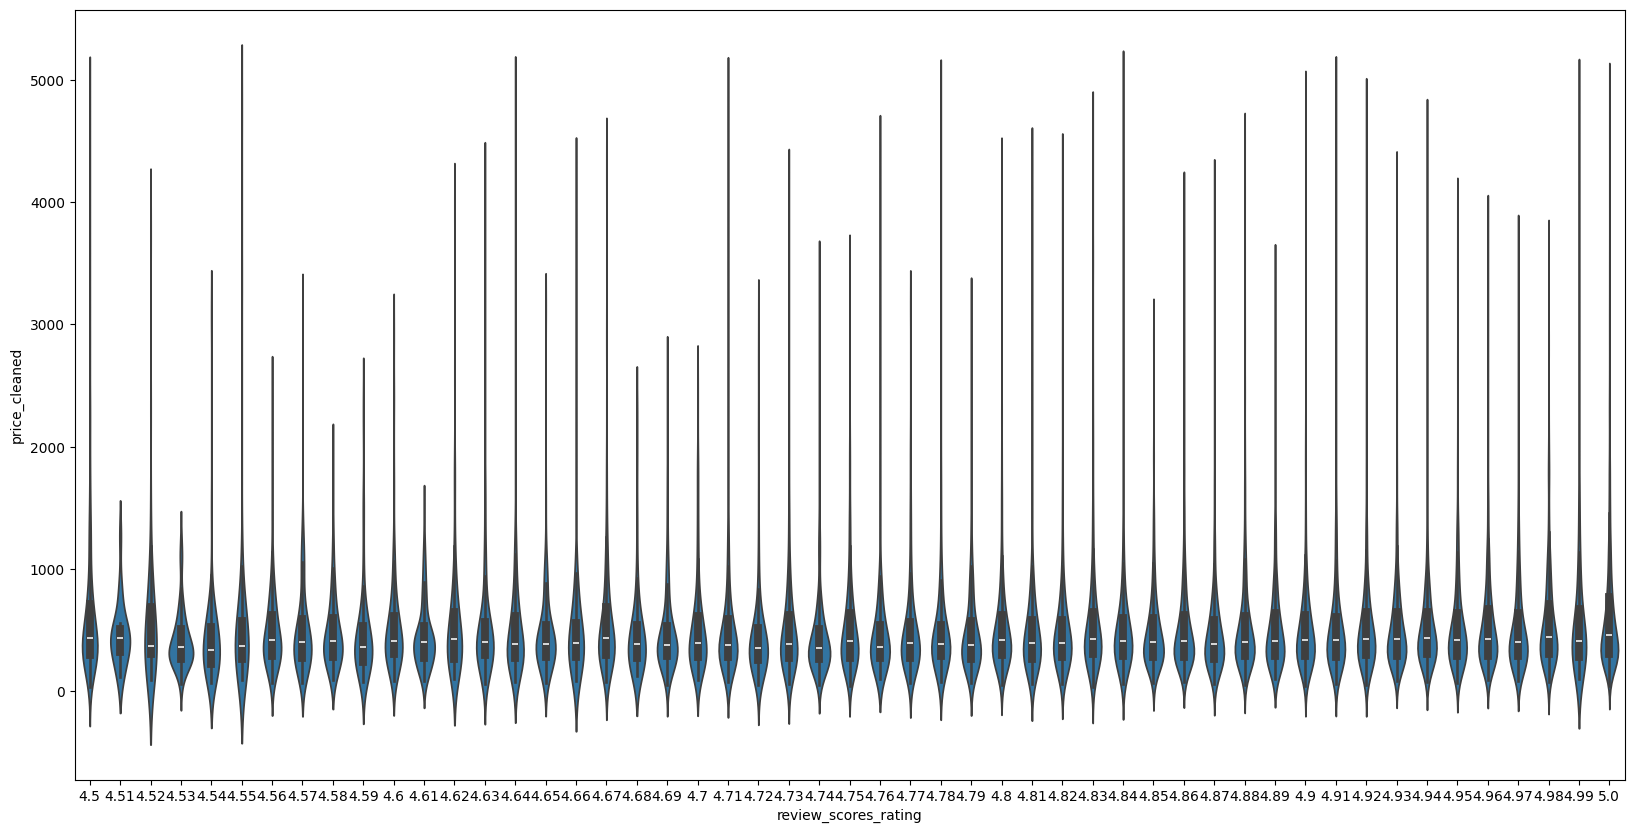

In [261]:
import seaborn as sns

plt.figure(figsize=[20,10])

df_plot_filtrado = df_treatment[
    df_treatment["review_scores_rating"].between(4.5, 5)
]

ax = sns.violinplot(x="review_scores_rating", y="price_cleaned", data=df_plot_filtrado)

# plt.xlim(4,5.1)

plt.show()


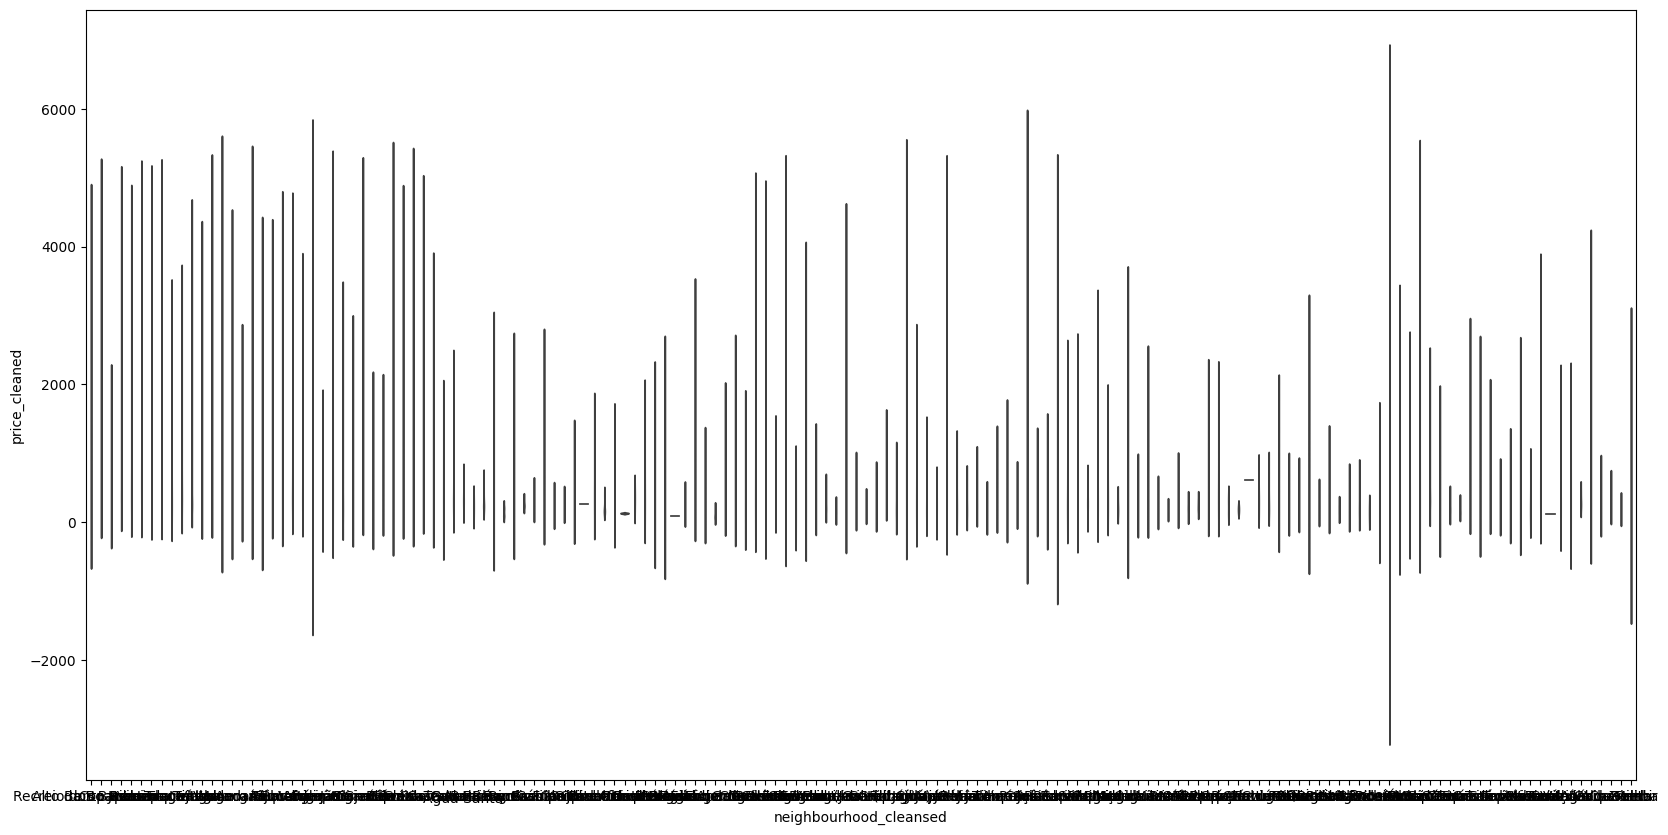

In [262]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="neighbourhood_cleansed", y="price_cleaned", data=df_treatment, inner=None)

# ax.set_yscale("log")

plt.show()


In [263]:
df_treatment['bairro_perigoso'].value_counts()

bairro_perigoso
0    38875
1     3274
Name: count, dtype: int64

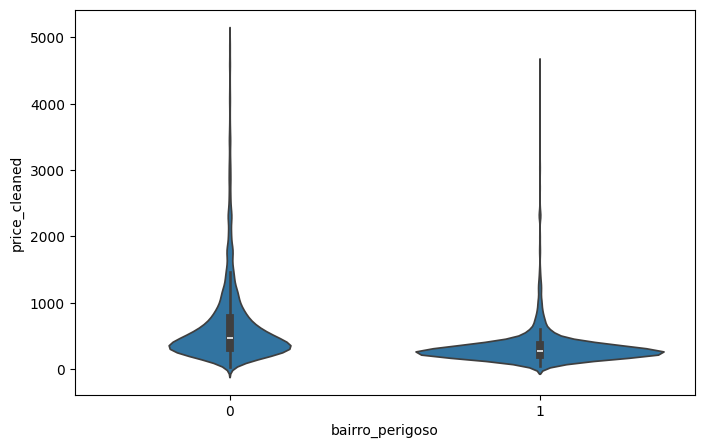

In [264]:
import seaborn as sns

plt.figure(figsize=[8,5])

ax = sns.violinplot(x="bairro_perigoso", y="price_cleaned", data=df_treatment)

# plt.xlim(4,5.1)

plt.show()


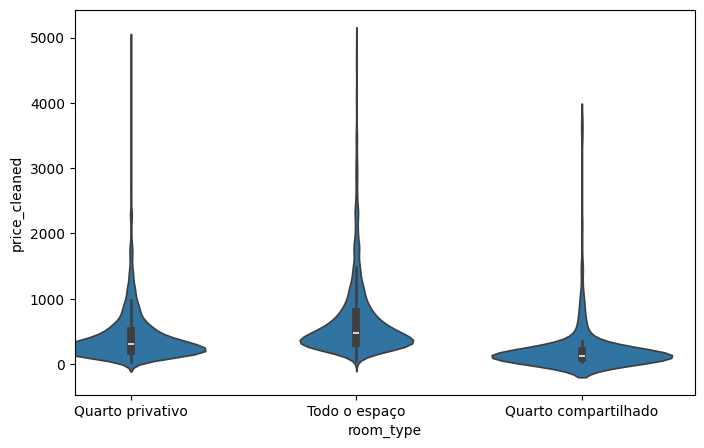

In [265]:
plt.figure(figsize=[8,5])

ax = sns.violinplot(df_treatment, x='room_type', y='price_cleaned')

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()

# Previsão de Preços

## Regressão sem Cuidado de Bairros ou Tipo de Quartos


### DecisionTree

In [266]:
colunas_para_modelos = ['id', 'latitude', 'longitude', 'host_is_superhost', 'bairro_perigoso', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name', 'minimum_nights', 'price_cleaned']

In [267]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.base import clone
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_treatment[colunas_para_modelos].copy()

df_arvore_regressora.dropna(inplace=True)

Primeiro vamos tratar separando os room types

In [268]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [269]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'room_type']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

Text(0.5, 1.0, 'Correlation Heatmap')

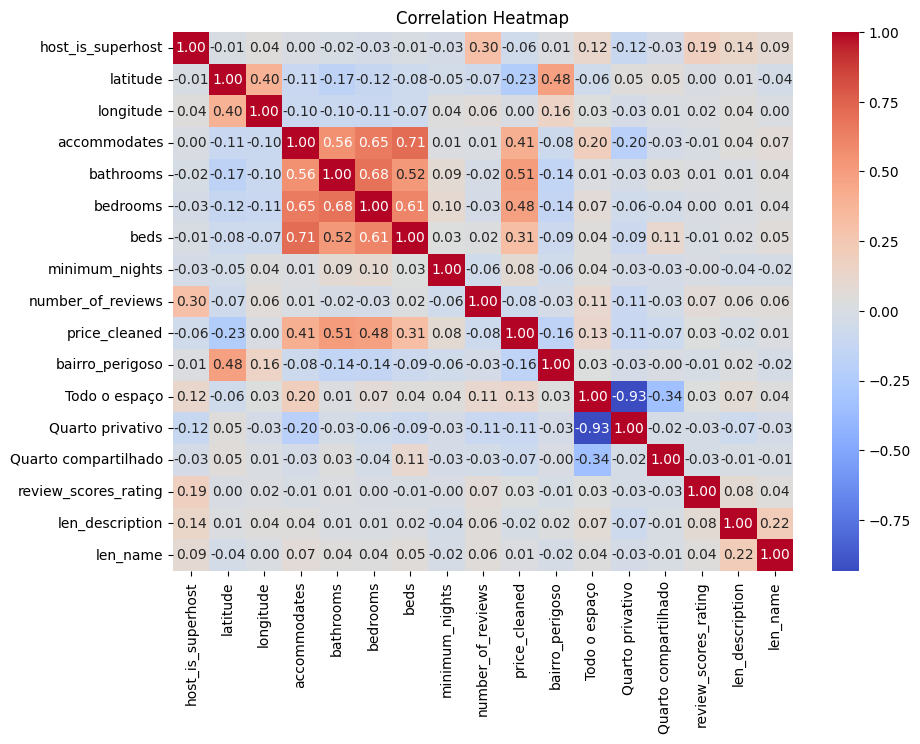

In [270]:
corr = df_arvore_regressora[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado', 'review_scores_rating', 'len_description', 'len_name'
    ]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [275]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [276]:
arvore_regressora = DecisionTreeRegressor(
    max_depth=6, 
    min_samples_leaf=100,
    random_state=RANDOM_SEED
    )

In [277]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [278]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [279]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [280]:
y_pred_arvore = pipeline_arvore.predict(X_test)

In [281]:
print("R² Score:", r2_score(y_test, y_pred_arvore))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_arvore))

R² Score: 0.34327315296585326
Root mean squared error: 438.25901335711404


In [282]:
from xgboost import XGBRegressor

precomputador_do_grupo =  ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')
    
pipeline_xgb = Pipeline(steps=[
    ('pre-processamento', precomputador_do_grupo),
    ('modelo', XGBRegressor(
        n_estimators=1000,
        max_depth=8,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.6,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

r2 = r2_score(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
print(f"R² Score: {r2:.4f}")
print(f"Root mean squared error: {rmse:.4f}\n")

R² Score: 0.4659
Root mean squared error: 395.2335



In [283]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"RMSE do Dummy (Média): {root_mean_squared_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -0.00021790944856037164
RMSE do Dummy (Média): 540.86


Ou seja, nosso modelo está realmente tendo algum efeito quando comparado com a média, está performando melhor que sem um modelo

In [284]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_arvore      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro (%)'] = ((df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'])*100


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro (%)'] >=10].head())

             id_imovel  preço_real  preço_previsto    erro (%)
0  1653057557453844545      320.00      565.713703   76.785532
1   575180150926936182      388.00      246.717653   36.412976
2  1493799267536922286      711.33      858.040907   20.624873
3  1101369892779590702      571.00      445.881707   21.912135
5  1566352263480162435      347.00      714.057325  105.780209


### Regressão linear

Acredito que a arvore de decisão vai lidar melhor com esse tipo de dados, mas vamos testar com regressões lineares e robust scaler

In [285]:
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
RANDOM_SEED = 42

df_lasso = df_treatment[colunas_para_modelos].copy()

df_lasso.dropna(inplace=True)

In [286]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_lasso[['room_type']])
one_hot = enc.transform(df_lasso[['room_type']]).toarray()
df_lasso[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

In [287]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

In [288]:
X = df_lasso.drop(columns=['price_cleaned'])
y = df_lasso['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [289]:
precomputador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

pipeline_lasso = Pipeline(steps=[
    ('pre-processamento', precomputador),
    
    ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
    
    ('modelo', Lasso(alpha=0.0001, max_iter=5000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

In [290]:
print("R² Score:", r2_score(y_test, y_pred_lasso))
print("Root mean squared error:", root_mean_squared_error(y_test,y_pred_lasso))

R² Score: 0.3076589387634331
Root mean squared error: 449.9854963331372


In [291]:
df_lasso = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred_lasso      # A nota que a árvore calculou
})
df_lasso.reset_index(drop=True, inplace=True)
df_lasso['erro'] = (df_lasso['preço_real'] - df_lasso['preço_previsto']).abs() / df_lasso['preço_real'] 


fig = px.line(df_lasso, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_lasso[df_lasso['erro'] >=0.1].head())

             id_imovel  preço_real  preço_previsto      erro
0  1653057557453844545      320.00      499.633480  0.561355
1   575180150926936182      388.00      230.993846  0.404655
2  1493799267536922286      711.33     1140.974148  0.604001
3  1101369892779590702      571.00      437.770843  0.233326
4              2482494      675.00      887.145367  0.314289


## Regressão com Cuidado de Bairros ou Tipos de Quartos

### Bairros

In [292]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'len_description', 'len_name']


dfs_por_bairro = {
    nome_grupo: dados[colunas_desejadas].dropna()
    for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')
}

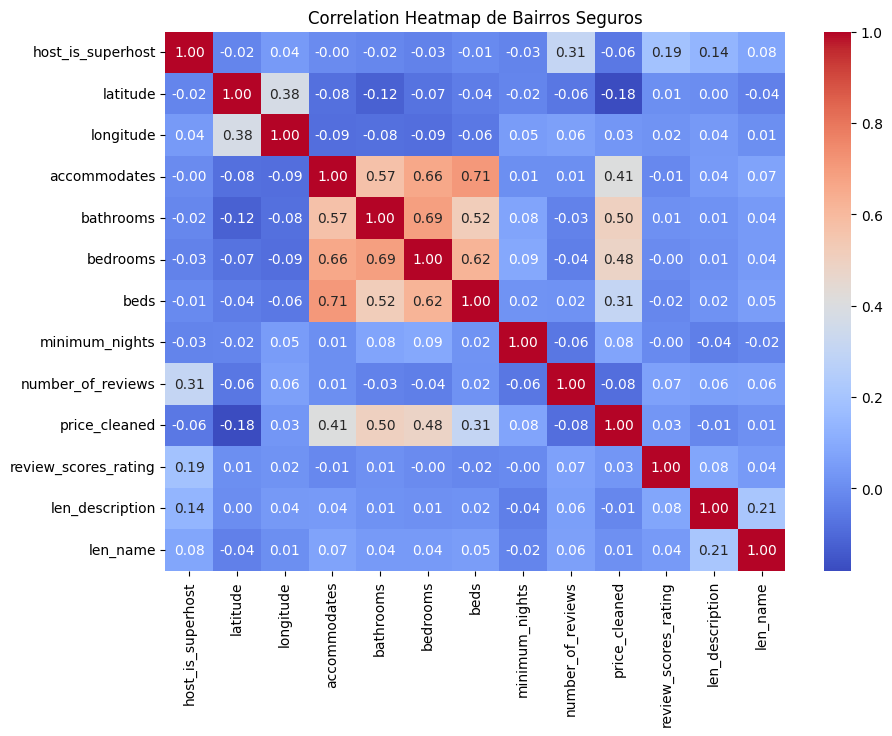

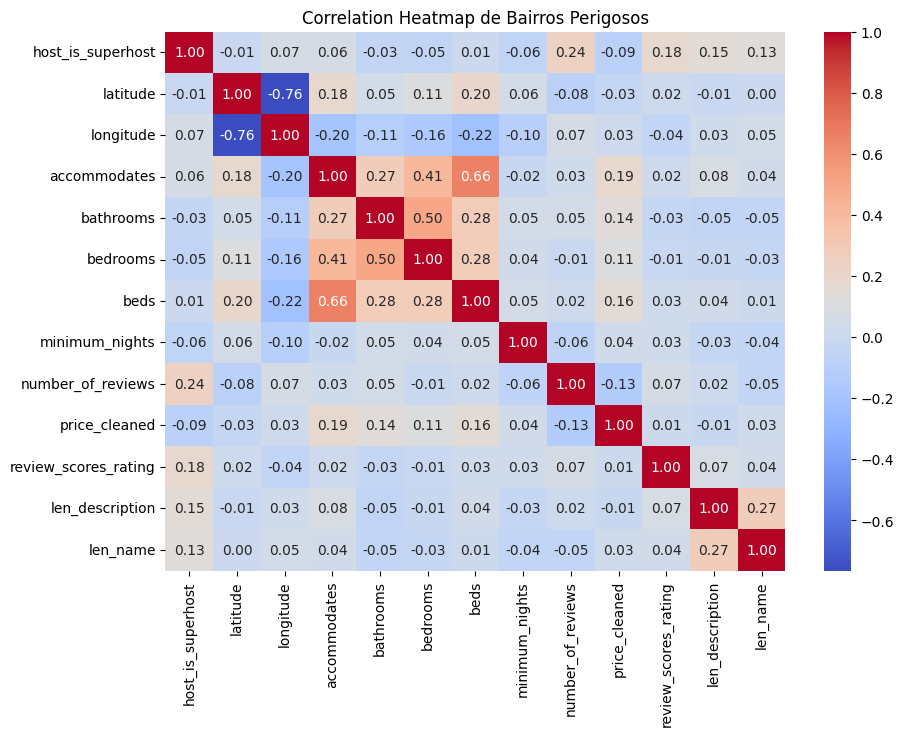

In [293]:
import seaborn as sns
plt.figure(figsize=(10, 7))
corr = dfs_por_bairro[0][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Seguros')
plt.show()

corr = dfs_por_bairro[1][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Perigosos')
plt.show()

In [294]:
cat_cols = ['host_is_superhost']#, 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'len_description', 'len_name']

In [295]:
for bairro, dfs_escolhido in dfs_por_bairro.items():
    print("Seguro" if bairro == 0 else "Perigoso")

Seguro
Perigoso


#### Arvore

In [296]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [297]:
modelos_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

predicoes_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

metricas_pricing = { "bairro":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        },
                    "tipos_de_quarto":{
                            "arvore_normal": {},
                            "arvore_xgboost": {},
                            "lasso": {}
                        }
}

In [298]:
MODELO_ATUAL = "arvore_normal"
CASO = "bairro"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_pricing[CASO][MODELO_ATUAL][status_bairro] = pipeline_atual
    
    predicoes_pricing[CASO][MODELO_ATUAL][status_bairro] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    
    metricas_pricing[CASO][MODELO_ATUAL][status_bairro] = {
        'R2': r2, 
        'RMSE': rmse
    }


--- Treinando arvore_normal para o grupo: Seguro ---
R² Score: 0.3709
Root mean squared error: 466.2398

--- Treinando arvore_normal para o grupo: Perigoso ---
R² Score: 0.1052
Root mean squared error: 159.5863


#### XGBoost

In [299]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: 0 ---


R² Score: 0.4469
Root mean squared error: 437.1756


--- Treinando arvore_xgboost para o grupo: 1 ---
R² Score: -0.5351
Root mean squared error: 209.0270



#### Lasso

In [300]:
precomputador_lasso_bairro = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

In [301]:
from sklearn.base import clone

MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = clone(precomputador_lasso_bairro)
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    rmse = root_mean_squared_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando lasso para o grupo: 0 ---
R² Score: 0.3802
Root mean squared error: 462.8108


--- Treinando lasso para o grupo: 1 ---
R² Score: 0.1333
Root mean squared error: 157.0617



### Tipos de Quartos

In [302]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna() 
    for nome_grupo, dados in df_treatment.groupby('room_type')
}

In [303]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

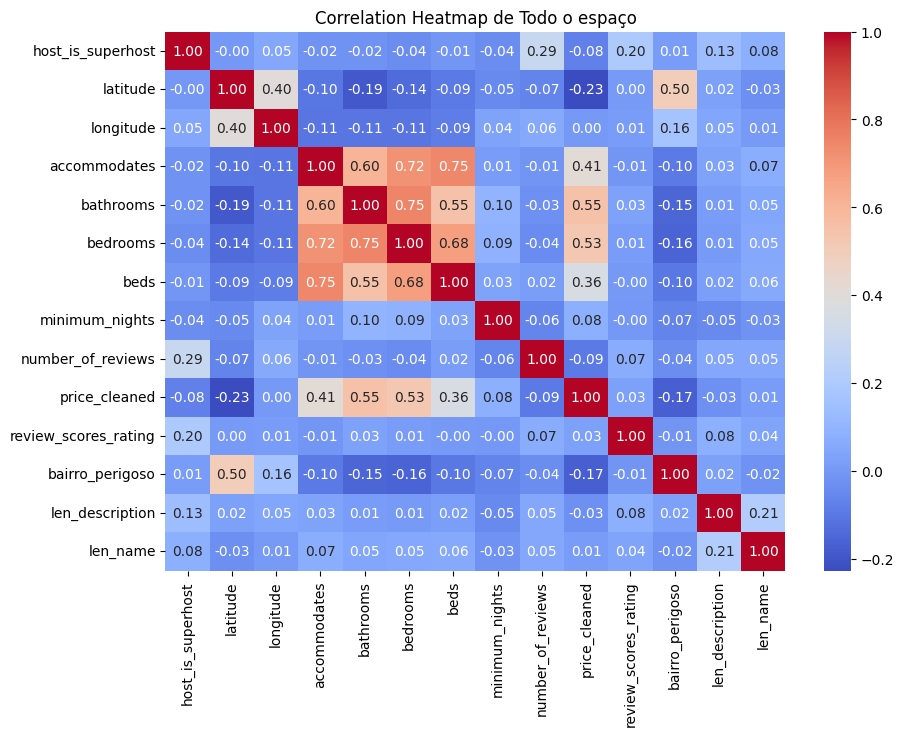

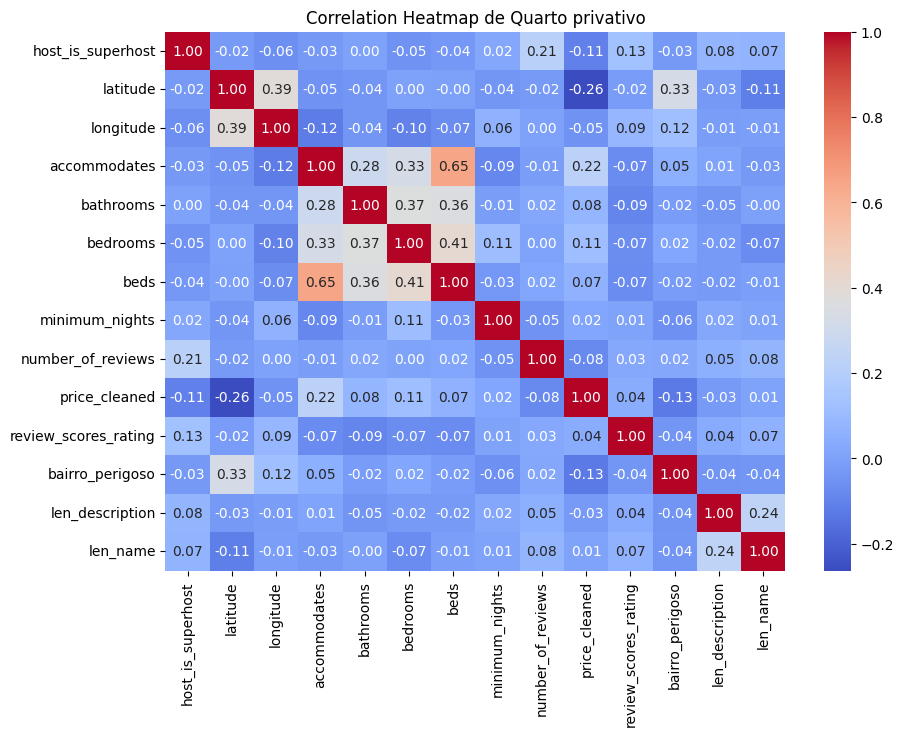

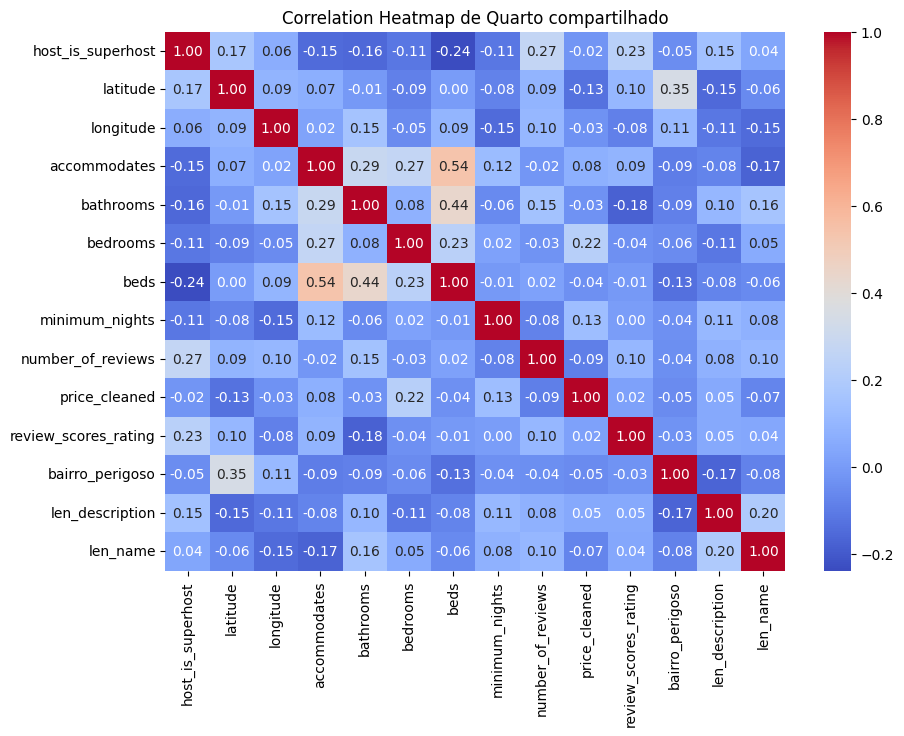

In [304]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'price_cleaned', 'review_scores_rating', 'bairro_perigoso', 'len_description', 'len_name'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

#### Arvore

In [305]:
cat_cols = ['host_is_superhost', 'bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']#, 'len_description', 'len_name']

In [306]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [307]:
MODELO_ATUAL = "arvore_normal"
CASO = "tipos_de_quarto"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    rmse = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0000
Root mean squared error: 471.1237

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.2324
Root mean squared error: 288.2302

--- Treinando arvore_normal para o grupo: Todo o espaço ---
R² Score: 0.4010
Root mean squared error: 441.0162


Leve piora comparado ao modelo analisando tudo e comparando com "Todo o espaço"

In [308]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    rmse = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---
R² Score: -0.0354
Root mean squared error: 479.3804


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: 0.3396
Root mean squared error: 267.3297


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.4746
Root mean squared error: 413.0500



In [309]:
len(dfs_por_quartos["Todo o espaço"]) / len(df)

0.5297559173116007

In [310]:
(len(dfs_por_quartos["Todo o espaço"]) + len(dfs_por_quartos["Quarto privativo"]) + len(dfs_por_quartos["Quarto compartilhado"]) )/ len(df)

0.5709564182045861

Resultado muito bom com XGBoost, principalmente para os dados de todo o espaço

In [311]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_pricing[CASO]['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_pricing[CASO]['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro (%)'] = ((df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real'])*100

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto    erro (%)
0             54225898      490.75      570.497314   16.250090
1  1540013477982973425      349.96      730.679688  108.789487
2              8319458      667.00      837.542419   25.568579
3             35495235      282.50      348.434479   23.339638
5  1139850497492167199      189.00      371.876404   96.760002


#### Lasso

In [312]:
precomputador_lasso_quartos = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

In [313]:
from sklearn.base import clone

MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['price_cleaned'])
    y_grupo = df_grupo['price_cleaned'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = clone(precomputador_lasso_quartos)
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    rmse = root_mean_squared_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': rmse}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: -0.1959
Root mean squared error: 515.1883


--- Treinando lasso para o grupo: Quarto privativo ---
R² Score: 0.2888
Root mean squared error: 277.4227


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: 0.4217
Root mean squared error: 433.3322



Modelos de lasso aqui se torna melhor que arvore regressora. $R^2_{Score}$ = 0.3342613615652218 em arvore sem separação de quartos.

Anuncios que se alugam todo o espaço esta prevendo melhor, provavelmente os outros ainda estão piorando a analise feita anteriormente, note ainda que quarto compartilhado é a pior predição de todas

In [314]:
for room in room_trad.values():
    print("O número de dados para o tipo de anúncio", room ,len(dfs_por_quartos[room]))

O número de dados para o tipo de anúncio Todo o espaço 25806
O número de dados para o tipo de anúncio Quarto privativo 1764
O número de dados para o tipo de anúncio Quarto compartilhado 243


Talves o problema dos quartos compartilhados esteja na quantidade de dados, poucos para se tirar uma estatística concisa. O dataset tem apenas 333 dados no total. Ao dividir em treino e teste (80/20), o conjunto de treino tem 266, podendo pegar poucos outlier do teste que possui cerca de 66 imóveis.

In [315]:
dfs_por_quartos["Quarto compartilhado"].price_cleaned.describe()

count     243.000000
mean      197.644979
std       364.393433
min        47.470000
25%        90.645000
50%       115.000000
75%       170.500000
max      3550.000000
Name: price_cleaned, dtype: float64

Outlier grande de 1544 para o restante dos dados, como pode ser visto, e pode estar estragando a regressão ou o teste.

In [316]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 'Todo o espaço' 

y_real = predicoes_pricing[CASO]['lasso'][nome_do_grupo]['y_test']
y_previsto = predicoes_pricing[CASO]['lasso'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_quartos[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['price_cleaned'])
y_grupo = df_grupo_original['price_cleaned'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'preço_real': y_real,            
    'preço_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro (%)'] = ((df_grupo['preço_real'] - df_grupo['preço_previsto']).abs() / df_grupo['preço_real'])*100

fig = px.line(df_grupo, y=['preço_real', 'preço_previsto'], 
              title=f"Preço Real vs Previsto - {nome_do_grupo}")
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para Todo o espaço:
             id_imovel  preço_real  preço_previsto    erro (%)
1  1540013477982973425      349.96      550.241526   57.229834
2              8319458      667.00     1203.610753   80.451387
3             35495235      282.50      349.706788   23.790014
4             16452851      317.00      388.548677   22.570561
5  1139850497492167199      189.00      410.356683  117.119938


In [317]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [318]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [319]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           34351
Quarto privativo         7298
Quarto compartilhado      481
Name: count, dtype: int64

# Previsão de Rating
Acredito que essa previsão seja extremamente difícil, devido a como cada tipo de pessoa da as notas, sem contar que acredito que é muito mais fácil alguém dar uma nota "ruim" do que "boa", afim de reclamar de algo.

Acredito ainda que clientes que pagam mais caro possuam uma exigência maior do que os que pagam mais caro, afinal, quanto mais se paga, mais cuidado, espaço, conforto, etc. se requer.

**Talvez fazer por multiclass**, em intervalos de 0-1, 1-2, 2-3, 3-4, 4-4,5 e 4,5-5. 

### Bairros Seguros e Perigosos

In [320]:
df_treatment.review_scores_rating.describe()

count    34223.000000
mean         4.806345
std          0.375815
min          0.000000
25%          4.770000
50%          4.920000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

In [321]:
colunas_desejadas = [
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 
    'review_scores_rating', 'price_cleaned', 'minimum_nights', 'room_type', 'len_description', 'len_name'
]

dfs_por_bairro = {
    nome_grupo: dados[colunas_desejadas].dropna().query("review_scores_rating >= 0 and number_of_reviews >=5")
    for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')
}

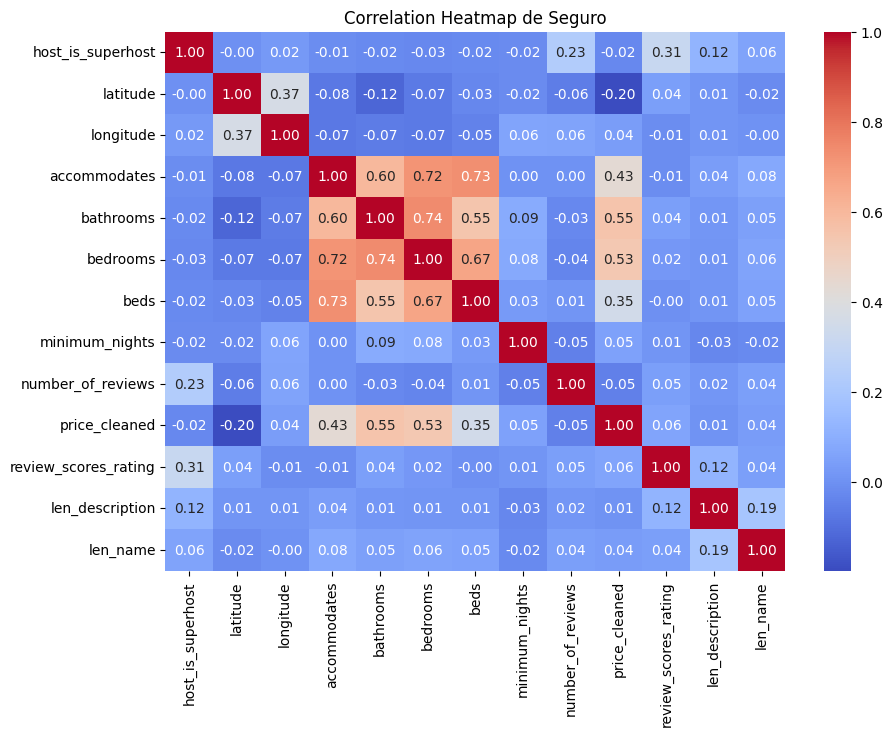

19250


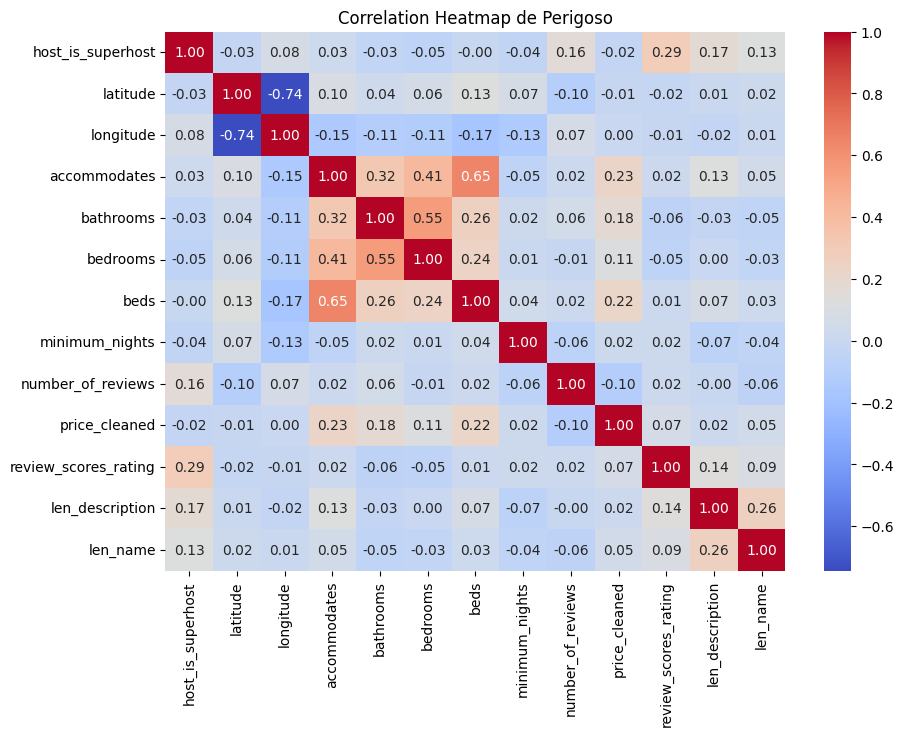

1633


In [322]:
for bairro, df_grupo in dfs_por_bairro.items():
    tipo_bairro = 'Seguro' if bairro == 0 else 'Perigoso'
    plt.figure(figsize=(10, 7))
    corr = df_grupo[[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'price_cleaned', 'review_scores_rating', 'len_description', 'len_name'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {tipo_bairro}' )
    plt.show()
    print(len(df_grupo))

In [323]:
cat_cols = ['host_is_superhost', 'room_type']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']#, 'len_description', 'len_name']

In [324]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [325]:
modelos_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_bairro = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

#### Arvore Regressora

In [326]:
from sklearn.metrics import mean_absolute_error

MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = mean_absolute_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}")
    
    modelos_por_bairro[MODELO_ATUAL][status_bairro] = pipeline_atual
    
    predicoes_por_bairro[MODELO_ATUAL][status_bairro] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    
    metricas_por_bairro[MODELO_ATUAL][status_bairro] = {
        'R2': r2, 
        'MAE': mae
    }


--- Treinando arvore_normal para o grupo: Seguro ---
R² Score: 0.1162
Mean absolut error: 0.1234

--- Treinando arvore_normal para o grupo: Perigoso ---
R² Score: 0.1521
Mean absolut error: 0.1236


#### XGBoost

In [327]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.01,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = root_mean_squared_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_por_bairro[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_bairro[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_bairro[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_xgboost para o grupo: Seguro ---
R² Score: 0.1422
Mean absolut error: 0.1750


--- Treinando arvore_xgboost para o grupo: Perigoso ---
R² Score: 0.2026
Mean absolut error: 0.1685



In [328]:
import pandas as pd
import plotly.express as px

nome_do_grupo = 0

y_real = predicoes_por_bairro['arvore_xgboost'][nome_do_grupo]['y_test']
y_previsto = predicoes_por_bairro['arvore_xgboost'][nome_do_grupo]['y_pred']

df_grupo_original = dfs_por_bairro[nome_do_grupo].dropna()
X_grupo = df_grupo_original.drop(columns=['review_scores_rating'])
y_grupo = df_grupo_original['review_scores_rating'].values

_, X_test_grupo, _, _ = train_test_split(
    X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
)

df_grupo = pd.DataFrame({
    'id_imovel': X_test_grupo['id'], 
    'rating_real': y_real,            
    'rating_previsto': y_previsto     
})

df_grupo.reset_index(drop=True, inplace=True)
df_grupo['erro absoluto'] = (df_grupo['rating_previsto'] - df_grupo['rating_real'])
df_grupo['erro (%)'] = ((df_grupo['rating_real'] - df_grupo['rating_previsto']).abs() / df_grupo['rating_real'])*100

fig = px.line(df_grupo, y=['rating_real', 'rating_previsto'], 
              title=f"Nota Real vs Previsto - {nome_do_grupo}")
fig.update_layout(
    width=1500,
    height=800
)
fig.show()

print(f"Exemplos com erro >= 10% para {nome_do_grupo}:")
print(df_grupo[df_grupo['erro (%)'] >= 10].head())

Exemplos com erro >= 10% para 0:
               id_imovel  rating_real  rating_previsto  erro absoluto  \
29   1337197308635817633         4.43         4.886215       0.456215   
55   1398578001544326219         4.20         4.742893       0.542893   
158             44226806         4.29         4.731630       0.441630   
228             47919819         4.08         4.774264       0.694264   
271  1517294238578686032         4.31         4.759415       0.449415   

      erro (%)  
29   10.298312  
55   12.926029  
158  10.294402  
228  17.016283  
271  10.427255  


#### Lasso

In [329]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_bairro.items():
    status_bairro = "Seguro" if nome_grupo == 0 else "Perigoso"
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {status_bairro} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.001, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_pricing[CASO][MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_pricing[CASO][MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_pricing[CASO][MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Seguro ---
R² Score: 0.1237
Mean absolut error: 0.1232


--- Treinando lasso para o grupo: Perigoso ---
R² Score: 0.0585
Mean absolut error: 0.1279



In [330]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"MAE do Dummy (Média): {mean_absolute_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -0.0069335248443096464
MAE do Dummy (Média): 0.14


### Quartos

In [331]:
colunas_desejadas = ['id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name']

dfs_por_quartos = {
    nome_grupo: dados[colunas_desejadas].dropna().query("review_scores_rating >= 4 and number_of_reviews >=10")
    for nome_grupo, dados in df_treatment.groupby('room_type')
}

In [332]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [333]:
cat_cols = ['host_is_superhost', 'bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned', 'len_description', 'len_name']

In [334]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [335]:
modelos_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_quarto = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [336]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = mean_absolute_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolute error: {mae:.4f}")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'mae': mae}


--- Treinando arvore_normal para o grupo: Quarto compartilhado ---
R² Score: -0.0935
Mean absolute error: 0.2031

--- Treinando arvore_normal para o grupo: Quarto privativo ---
R² Score: 0.0589
Mean absolute error: 0.1439

--- Treinando arvore_normal para o grupo: Todo o espaço ---


R² Score: 0.1884
Mean absolute error: 0.1040


In [337]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = mean_absolute_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolut error: {mae:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'RMSE': mae}


--- Treinando arvore_xgboost para o grupo: Quarto compartilhado ---
R² Score: 0.2225
Mean absolut error: 0.1554


--- Treinando arvore_xgboost para o grupo: Quarto privativo ---
R² Score: -0.2115
Mean absolut error: 0.1567


--- Treinando arvore_xgboost para o grupo: Todo o espaço ---
R² Score: 0.2371
Mean absolut error: 0.1000



In [338]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_quartos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=2, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {rmse:.4f}\n")
    
    modelos_por_quarto[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_quarto[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_quarto[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Quarto compartilhado ---
R² Score: -0.0906
Root mean squared error: 433.3322


--- Treinando lasso para o grupo: Quarto privativo ---
R² Score: -0.0060
Root mean squared error: 433.3322


--- Treinando lasso para o grupo: Todo o espaço ---
R² Score: -0.0004
Root mean squared error: 433.3322



### Preço

In [339]:
colunas_desejadas = [
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 
    'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name'
]
limites = [0, 200, 400, 600, 1000]
nomes_faixas = ['Barato', 'Médio', 'Caro', 'Muito caro']

df_treatment['faixa_preco'] = pd.cut(
    df_treatment['price_cleaned'], 
    bins=limites, 
    labels=nomes_faixas
)

colunas_finais = colunas_desejadas + ['faixa_preco']

dfs_por_precos = {
    nome_grupo: dados[colunas_finais].dropna().query("review_scores_rating >= 4 and number_of_reviews >= 10")
    for nome_grupo, dados in df_treatment.groupby('faixa_preco', observed=False)
}

In [340]:
cat_cols = ['bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_cleaned', 'len_description', 'len_name']

In [341]:
precomputador_arvore = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [342]:
modelos_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

predicoes_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

metricas_por_preco = {
    "arvore_normal": {},
    "arvore_xgboost": {},
    "lasso": {}
}

In [343]:
MODELO_ATUAL = "arvore_normal"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_arvore),
        ('modelo', clone(arvore_regressora))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_arvore = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_arvore)
    mae = root_mean_squared_error(y_test, y_pred_arvore)
    print(f"R² Score: {r2:.4f}")
    print(f"Mean absolute error: {rmse:.4f}")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_arvore
    }
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_normal para o grupo: Barato ---
R² Score: 0.0852
Mean absolute error: 433.3322

--- Treinando arvore_normal para o grupo: Médio ---
R² Score: 0.0364
Mean absolute error: 433.3322

--- Treinando arvore_normal para o grupo: Caro ---
R² Score: -0.0303
Mean absolute error: 433.3322

--- Treinando arvore_normal para o grupo: Muito caro ---
R² Score: 0.0264
Mean absolute error: 433.3322


In [344]:
from xgboost import XGBRegressor

MODELO_ATUAL = "arvore_xgboost"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    precomputador_do_grupo = clone(precomputador_arvore)
    
    pipeline_xgb = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('modelo', XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_SEED,
            n_jobs=-1
        ))
    ])
    
    pipeline_xgb.fit(X_train, y_train)
    y_pred_xgb = pipeline_xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred_xgb)
    mae = mean_absolute_error(y_test, y_pred_xgb)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {mae:.4f}\n")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_xgb
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {'y_test': y_test, 'y_pred': y_pred_xgb}
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando arvore_xgboost para o grupo: Barato ---
R² Score: 0.2623
Root mean squared error: 0.1316


--- Treinando arvore_xgboost para o grupo: Médio ---
R² Score: 0.0690
Root mean squared error: 0.1121


--- Treinando arvore_xgboost para o grupo: Caro ---
R² Score: 0.0057
Root mean squared error: 0.1165


--- Treinando arvore_xgboost para o grupo: Muito caro ---
R² Score: 0.0015
Root mean squared error: 0.1099



In [345]:
MODELO_ATUAL = "lasso"

for nome_grupo, df_grupo in dfs_por_precos.items():
    print(f"\n--- Treinando {MODELO_ATUAL} para o grupo: {nome_grupo} ---")
    df_grupo.dropna(inplace=True)
    
    X_grupo = df_grupo.drop(columns=['review_scores_rating'])
    y_grupo = df_grupo['review_scores_rating'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_grupo, y_grupo, test_size=0.2, random_state=RANDOM_SEED
    )
    
    precomputador_do_grupo = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), num_cols),
            ('cat', OneHotEncoder(sparse_output=False), cat_cols)
        ],
        remainder='drop'
    )
    
    pipeline_atual = Pipeline(steps=[
        ('pre-processamento', precomputador_do_grupo),
        ('polinomial', PolynomialFeatures(degree=1, include_bias=False)),
        ('modelo', Lasso(alpha=0.89, max_iter=5000))
    ])
    
    pipeline_atual.fit(X_train, y_train)
    y_pred_lasso = pipeline_atual.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)
    mae = mean_absolute_error(y_test, y_pred_lasso)
    print(f"R² Score: {r2:.4f}")
    print(f"Root mean squared error: {mae:.4f}\n")
    
    modelos_por_preco[MODELO_ATUAL][nome_grupo] = pipeline_atual
    predicoes_por_preco[MODELO_ATUAL][nome_grupo] = {
        'y_test': y_test,
        'y_pred': y_pred_lasso
    }
    metricas_por_preco[MODELO_ATUAL][nome_grupo] = {'R2': r2, 'MAE': mae}


--- Treinando lasso para o grupo: Barato ---
R² Score: -0.0065
Root mean squared error: 0.1574


--- Treinando lasso para o grupo: Médio ---
R² Score: -0.0009
Root mean squared error: 0.1182


--- Treinando lasso para o grupo: Caro ---
R² Score: -0.0000
Root mean squared error: 0.1161


--- Treinando lasso para o grupo: Muito caro ---
R² Score: -0.0002
Root mean squared error: 0.1098



A faixa de preço não influencia tanto

### Previsão por multiclass
 + Classe 1: < 4.0 (Acomodações ruins / Críticas)
 + Classe 2: 4.0 - 4.5 (Acomodações medianas, com problemas pontuais)
 + Classe 3: 4.5 - 4.75 (Acomodações boas)
 + Classe 4: 4.75 - 4.9 (Acomodações muito boas / Superhosts frequentes)
 + Classe 5: 4.9 - 5.0 (Acomodações excepcionais)

In [346]:
df_treatment.review_scores_rating.describe()

count    34223.000000
mean         4.806345
std          0.375815
min          0.000000
25%          4.770000
50%          4.920000
75%          5.000000
max          5.000000
Name: review_scores_rating, dtype: float64

In [347]:
colunas_desejadas = [
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 
    'review_scores_rating', 'price_cleaned', 'minimum_nights', 'bairro_perigoso', 'len_description', 'len_name'
]

In [348]:
categorias = [['Ruins', 'Medianas', 'Boas', 'Muito boas', 'Excepcionais']]

bins = [-0.1, 4.0, 4.5, 4.75, 4.9, 5.01]

labels = [
    "Ruins",
    "Medianas",
    "Boas",
    "Muito boas",
    "Excepcionais",
]

df_multiclass = df_treatment[colunas_desejadas].copy()

df_multiclass["classe_acomodacao"] = pd.cut(
    df_multiclass["review_scores_rating"], bins=bins, labels=labels, right=False
)

df_multiclass.dropna(inplace=True)

In [349]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [350]:
cat_cols = ['bairro_perigoso']
num_cols = ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_cleaned', 'len_description', 'len_name']

In [351]:
X = df_multiclass[cat_cols + num_cols]
y = df_multiclass['classe_acomodacao']

In [352]:
df_multiclass.classe_acomodacao.value_counts()

classe_acomodacao
Excepcionais    14965
Muito boas       6666
Boas             3979
Medianas         1635
Ruins             579
Name: count, dtype: int64

In [353]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="linear", C=1.0, gamma="scale", decision_function_shape="ovo", random_state=RANDOM_SEED, class_weight='balanced') #talvez mudar one-to-one
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

--- Relatório de Classificação ---
              precision    recall  f1-score   support

        Boas       0.21      0.09      0.12       849
Excepcionais       0.63      0.24      0.34      2916
    Medianas       0.07      0.17      0.10       329
  Muito boas       0.27      0.52      0.36      1345
       Ruins       0.04      0.24      0.06       126

    accuracy                           0.28      5565
   macro avg       0.25      0.25      0.20      5565
weighted avg       0.44      0.28      0.29      5565



In [354]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, criterion='gini', random_state=RANDOM_SEED, class_weight='balanced')

rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)
probabilities = rf_model.predict_proba(X_test)

target_names = [str(cls) for cls in sorted(y.unique())] 
print(classification_report(y_test, predictions, target_names=target_names))

              precision    recall  f1-score   support

        Boas       0.25      0.03      0.06       849
Excepcionais       0.54      0.93      0.68      2916
    Medianas       0.41      0.04      0.07       329
  Muito boas       0.30      0.10      0.15      1345
       Ruins       0.25      0.02      0.03       126

    accuracy                           0.52      5565
   macro avg       0.35      0.22      0.20      5565
weighted avg       0.42      0.52      0.41      5565



In [355]:
from sklearn.tree import DecisionTreeClassifier

decriontree_model = DecisionTreeClassifier(criterion='gini', random_state=RANDOM_SEED, min_samples_leaf=5, class_weight='balanced')

decriontree_model.fit(X_train, y_train)

predictions = decriontree_model.predict(X_test)
probabilities = decriontree_model.predict_proba(X_test)

target_names = [str(cls) for cls in sorted(y.unique())] 
print(classification_report(y_test, predictions, target_names=target_names))

              precision    recall  f1-score   support

        Boas       0.16      0.24      0.19       849
Excepcionais       0.58      0.33      0.42      2916
    Medianas       0.08      0.23      0.12       329
  Muito boas       0.27      0.28      0.27      1345
       Ruins       0.05      0.13      0.07       126

    accuracy                           0.29      5565
   macro avg       0.23      0.24      0.22      5565
weighted avg       0.40      0.29      0.33      5565



In [356]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=5, 
    random_state=RANDOM_SEED
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [357]:
y_pred_numerico = xgb_model.predict(X_test)

y_pred_texto = label_encoder.inverse_transform(y_pred_numerico)

y_test_texto = label_encoder.inverse_transform(y_test)

resultados = pd.DataFrame({
    'Real': y_test_texto,
    'Previsão do Modelo': y_pred_texto
})

print("Amostra das Previsões:")
print(resultados.head(10))

print("\n" + "="*50 + "\n")

print("Relatório de Classificação:")
print(classification_report(y_test_texto, y_pred_texto))

Amostra das Previsões:
           Real Previsão do Modelo
0  Excepcionais              Ruins
1  Excepcionais       Excepcionais
2    Muito boas         Muito boas
3  Excepcionais         Muito boas
4  Excepcionais               Boas
5  Excepcionais         Muito boas
6    Muito boas       Excepcionais
7    Muito boas               Boas
8  Excepcionais       Excepcionais
9  Excepcionais         Muito boas


Relatório de Classificação:
              precision    recall  f1-score   support

        Boas       0.19      0.27      0.22       796
Excepcionais       0.64      0.47      0.54      2993
    Medianas       0.06      0.11      0.08       327
  Muito boas       0.31      0.33      0.32      1333
       Ruins       0.06      0.12      0.08       116

    accuracy                           0.38      5565
   macro avg       0.25      0.26      0.25      5565
weighted avg       0.45      0.38      0.41      5565

